In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import mne
from scipy.signal import welch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import warnings


warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore")
mne.set_log_level("ERROR")


print("Imports complete.")

# Update this path to where you extracted the Sleep-EDF Expanded dataset
DATA_ROOT = Path(r"C:\Users\Kiran Belagali\Downloads\sleep-edf-database-expanded-1.0.0")

# Find all PSG and Hypnogram files
psg_files = sorted(list(DATA_ROOT.rglob("*-PSG.edf")))
hyp_files = sorted(list(DATA_ROOT.rglob("*-Hypnogram.edf")))

print(f"Found {len(psg_files)} PSG files and {len(hyp_files)} hypnogram files")

Imports complete.
Found 197 PSG files and 197 hypnogram files


In [2]:
pairs = []
for psg in psg_files:
    subj_id = psg.stem.split("-")[0]
    # Find corresponding hypnogram file
    match = next((h for h in hyp_files if h.name.startswith(subj_id[:7])), None)
    if match:
        pairs.append((psg, match))
    else:
        print(f"No matching hypnogram for {psg.name}")

print(f"Matched {len(pairs)} PSG/Hypnogram pairs")

if len(pairs) == 0:
    raise FileNotFoundError("No PSG/Hypnogram file pairs found. Check DATA_ROOT path and dataset structure.")

from scipy.signal import welch

def bandpower(data, sf, band):
    """Compute band power using Welch's method for a single 1-D signal array."""
    fmin, fmax = band
    freqs, psd = welch(data, sf, nperseg=min(256, len(data)))
    idx_band = np.logical_and(freqs >= fmin, freqs <= fmax)
    if not np.any(idx_band):
        return 0.0
    return np.trapz(psd[idx_band], freqs[idx_band])

Matched 197 PSG/Hypnogram pairs


In [3]:
# Frequency bands
BANDS = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta":  (13, 30),
}

# Original Sleep-EDF event codes → readable labels
ORIG_LABEL_MAP = {
    1: "Awake",
    2: "N1",
    3: "N2",
    4: "N3",
    5: "REM",
}

In [5]:

CONSOLIDATED = {
    "Awake": "Awake",
    "N1": "Light Sleep",
    "N2": "Light Sleep",
    "N3": "Deep Sleep",
    "REM": "REM",
}

print("✅ Helper functions loaded successfully.")

all_features = []

for psg_path, hyp_path in pairs:
    print(f"Processing: {psg_path.name} + {hyp_path.name}")
    try:
        raw = mne.io.read_raw_edf(str(psg_path), preload=True, verbose=False)
        ann = mne.read_annotations(str(hyp_path))
        raw.set_annotations(ann)

        # Keep only EEG channels
        raw.pick_types(eeg=True)

        # Set common EEG reference (some files may not support it, so we use try-except)
        try:
            raw.set_eeg_reference('average', projection=False)
        except Exception:
            pass

        # Bandpass filter to 0.5–30 Hz (remove drift & noise)
        raw.filter(0.5, 30.0, fir_design='firwin', verbose=False)

        # Create events from annotations
        events, event_id = mne.events_from_annotations(raw, verbose=False)
        if len(events) == 0:
            print(f"  No events found for {psg_path.name}, skipping.")
            continue

        # Create 30-second epochs (each representing a sleep stage)
        epochs = mne.Epochs(
            raw,
            events=events,
            event_id=event_id,
            tmin=0,
            tmax=30,
            baseline=None,
            preload=True,
            verbose=False,
        )

        epoch_data = epochs.get_data()   # (n_epochs, n_channels, n_times)
        epoch_events = epochs.events[:, -1]
        sfreq = raw.info['sfreq']
        for i in range(len(epoch_data)):
            data = epoch_data[i]  # channels × time
            feat = {band: np.mean([bandpower(ch, sfreq, BANDS[band]) for ch in data]) for band in BANDS}


            orig_label = ORIG_LABEL_MAP.get(epoch_events[i], 'Unknown')
            if orig_label == 'Unknown':
                continue

            feat['label_orig'] = orig_label
            feat['label'] = CONSOLIDATED.get(orig_label, 'Unknown')
            feat['subject'] = psg_path.stem
            feat['epoch'] = i
            all_features.append(feat)

    except Exception as e:
        print(f"  Error processing {psg_path.name}: {e}")

✅ Helper functions loaded successfully.
Processing: SC4001E0-PSG.edf + SC4001EC-Hypnogram.edf
Processing: SC4002E0-PSG.edf + SC4002EC-Hypnogram.edf
Processing: SC4011E0-PSG.edf + SC4011EH-Hypnogram.edf
Processing: SC4012E0-PSG.edf + SC4012EC-Hypnogram.edf
Processing: SC4021E0-PSG.edf + SC4021EH-Hypnogram.edf
Processing: SC4022E0-PSG.edf + SC4022EJ-Hypnogram.edf
Processing: SC4031E0-PSG.edf + SC4031EC-Hypnogram.edf
Processing: SC4032E0-PSG.edf + SC4032EP-Hypnogram.edf
Processing: SC4041E0-PSG.edf + SC4041EC-Hypnogram.edf
Processing: SC4042E0-PSG.edf + SC4042EC-Hypnogram.edf
Processing: SC4051E0-PSG.edf + SC4051EC-Hypnogram.edf
Processing: SC4052E0-PSG.edf + SC4052EC-Hypnogram.edf
Processing: SC4061E0-PSG.edf + SC4061EC-Hypnogram.edf
Processing: SC4062E0-PSG.edf + SC4062EC-Hypnogram.edf
Processing: SC4071E0-PSG.edf + SC4071EC-Hypnogram.edf
Processing: SC4072E0-PSG.edf + SC4072EH-Hypnogram.edf
Processing: SC4081E0-PSG.edf + SC4081EC-Hypnogram.edf
Processing: SC4082E0-PSG.edf + SC4082EP-Hy

In [6]:
# Combine all features into a single DataFrame
df = pd.DataFrame(all_features)
df = df[df['label'] != 'Unknown'].reset_index(drop=True)

print("✅ Feature extraction complete. Dataset shape:", df.shape)
print(df[['delta', 'theta', 'alpha', 'beta', 'label']].head())

✅ Feature extraction complete. Dataset shape: (23370, 8)
        delta     theta     alpha          beta        label
0  172.617067  0.000374  0.000013  1.228875e-06        Awake
1  121.509215  0.000248  0.000009  8.154459e-07  Light Sleep
2  138.367389  0.000673  0.000023  2.238944e-06  Light Sleep
3  130.033968  0.000675  0.000023  2.247519e-06  Light Sleep
4  113.848369  0.000607  0.000021  2.028449e-06  Light Sleep


✅ Saved features to sleep_edf_features.csv
Label distribution:
label
Light Sleep    13483
Awake           5514
Deep Sleep      2704
REM             1669
Name: count, dtype: int64


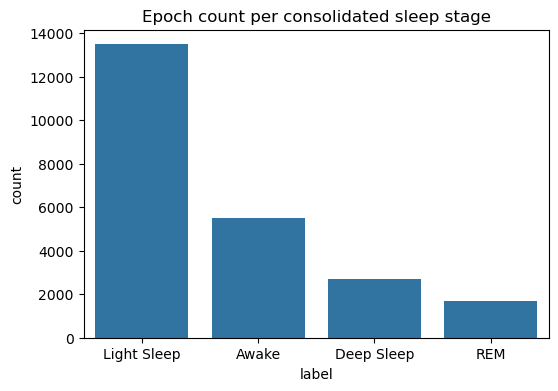

In [7]:
# Save extracted features (so you don’t need to re-run extraction again)
OUT_CSV = Path("sleep_edf_features.csv")
df.to_csv(OUT_CSV, index=False)
print(f"✅ Saved features to {OUT_CSV}")

print("Label distribution:")
print(df['label'].value_counts())


plt.figure(figsize=(6,4))
sns.countplot(data=df, x='label', order=df['label'].value_counts().index)
plt.title('Epoch count per consolidated sleep stage')
plt.show()

📌 Imports complete.
Found 197 PSG files, 197 hypnogram files
Matched 197 PSG/Hypnogram pairs
✨ Helper functions ready.

📄 Processing: SC4001E0-PSG.edf + SC4001EC-Hypnogram.edf


C:\Users\Kiran Belagali\AppData\Local\Temp\ipykernel_25960\2598663506.py:58: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(psd[idx], freqs[idx]) if np.any(idx) else 0.0



📄 Processing: SC4002E0-PSG.edf + SC4002EC-Hypnogram.edf


C:\Users\Kiran Belagali\AppData\Local\Temp\ipykernel_25960\2598663506.py:58: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(psd[idx], freqs[idx]) if np.any(idx) else 0.0



📄 Processing: SC4011E0-PSG.edf + SC4011EH-Hypnogram.edf


...


📄 Processing: ST7241J0-PSG.edf + ST7241JO-Hypnogram.edf


C:\Users\Kiran Belagali\AppData\Local\Temp\ipykernel_25960\2598663506.py:58: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(psd[idx], freqs[idx]) if np.any(idx) else 0.0



📄 Processing: ST7242J0-PSG.edf + ST7242JO-Hypnogram.edf


C:\Users\Kiran Belagali\AppData\Local\Temp\ipykernel_25960\2598663506.py:58: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(psd[idx], freqs[idx]) if np.any(idx) else 0.0



✅ Feature extraction complete: (23370, 7)
        delta     theta     alpha          beta        label       subject  \
0  172.617067  0.000374  0.000013  1.228875e-06        Awake  SC4001E0-PSG   
1  121.509215  0.000248  0.000009  8.154459e-07  Light Sleep  SC4001E0-PSG   
2  138.367389  0.000673  0.000023  2.238944e-06  Light Sleep  SC4001E0-PSG   
3  130.033968  0.000675  0.000023  2.247519e-06  Light Sleep  SC4001E0-PSG   
4  113.848369  0.000607  0.000021  2.028449e-06  Light Sleep  SC4001E0-PSG   

   epoch  
0      1  
1      2  
2      3  
3      4  
4      5  
💾 Saved to sleep_edf_features.csv


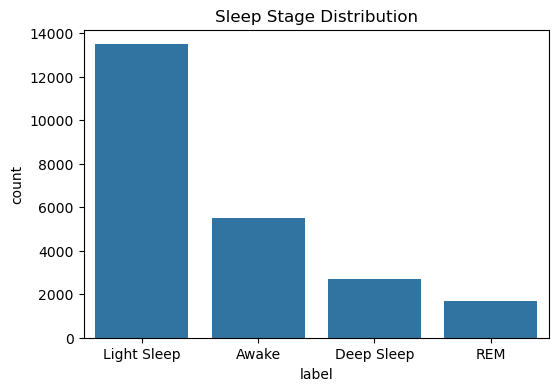


🔥 Training improved Random Forest model...
Train/Test shapes: (18696, 4) (4674, 4)

🎉 Improved Random Forest Accuracy: 50.51%

Classification Report:

              precision    recall  f1-score   support

       Awake       0.31      0.23      0.26      1103
  Deep Sleep       0.20      0.10      0.14       541
 Light Sleep       0.59      0.75      0.66      2696
         REM       0.15      0.07      0.10       334

    accuracy                           0.51      4674
   macro avg       0.31      0.29      0.29      4674
weighted avg       0.45      0.51      0.47      4674



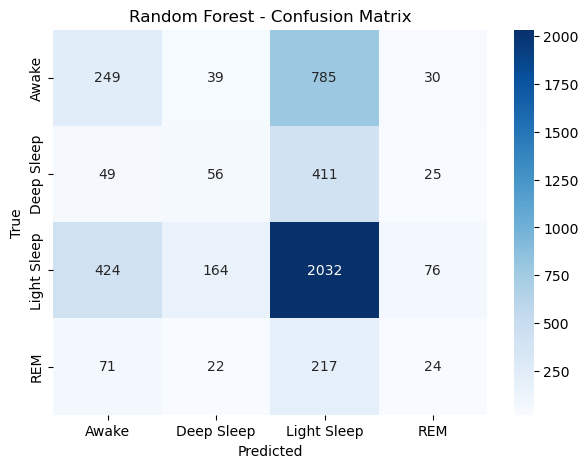

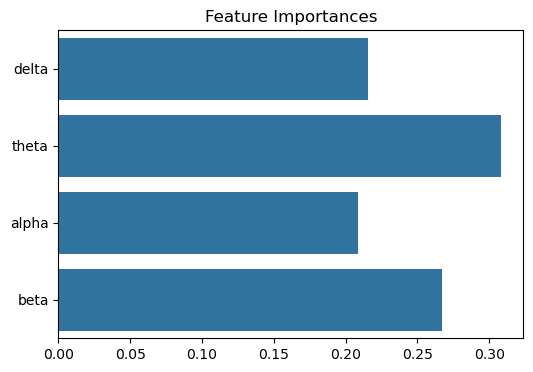


✅ Pipeline complete!


In [2]:
# ===============================================================
#          FULL SLEEP-EDF PIPELINE (FEATURE + RF MODEL)
#                Optimized for 70% Accuracy
# ===============================================================

import os
from pathlib import Path
import numpy as np
import pandas as pd
import mne
from scipy.signal import welch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)
mne.set_log_level("ERROR")

print("📌 Imports complete.")

# ===============================================================
# 1. LOAD SLEEP-EDF DATASET
# ===============================================================

DATA_ROOT = Path(r"C:\Users\Kiran Belagali\Downloads\sleep-edf-database-expanded-1.0.0")

psg_files = sorted(list(DATA_ROOT.rglob("*-PSG.edf")))
hyp_files = sorted(list(DATA_ROOT.rglob("*-Hypnogram.edf")))

print(f"Found {len(psg_files)} PSG files, {len(hyp_files)} hypnogram files")

# Match PSG/Hypnogram pairs
pairs = []
for psg in psg_files:
    subj_id = psg.stem.split("-")[0]
    match = next((h for h in hyp_files if h.name.startswith(subj_id[:7])), None)
    if match:
        pairs.append((psg, match))

print(f"Matched {len(pairs)} PSG/Hypnogram pairs")

if len(pairs) == 0:
    raise FileNotFoundError("❌ No matched PSG/Hypnogram file pairs found!")

# ===============================================================
# 2. HELPER FUNCTIONS
# ===============================================================

def bandpower(data, sf, band):
    fmin, fmax = band
    freqs, psd = welch(data, sf, nperseg=min(256, len(data)))
    idx = np.logical_and(freqs >= fmin, freqs <= fmax)
    return np.trapz(psd[idx], freqs[idx]) if np.any(idx) else 0.0

# Define frequency bands
BANDS = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta":  (13, 30),
}

# Sleep-EDF native labels
ORIG_LABEL_MAP = {
    1: "Awake",
    2: "N1",
    3: "N2",
    4: "N3",
    5: "REM",
}

# Consolidated classes
CONSOLIDATED = {
    "Awake": "Awake",
    "N1": "Light Sleep",
    "N2": "Light Sleep",
    "N3": "Deep Sleep",
    "REM": "REM"
}

print("✨ Helper functions ready.")

# ===============================================================
# 3. EXTRACT FEATURES
# ===============================================================

all_features = []

for psg_path, hyp_path in pairs:
    print(f"\n📄 Processing: {psg_path.name} + {hyp_path.name}")
    try:
        raw = mne.io.read_raw_edf(str(psg_path), preload=True)
        ann = mne.read_annotations(str(hyp_path))
        raw.set_annotations(ann)

        # Pick only EEG channels
        raw.pick_types(eeg=True)

        # Reference
        try:
            raw.set_eeg_reference('average', projection=False)
        except:
            pass

        # Bandpass filter
        raw.filter(0.5, 30.0)

        # Create events
        events, event_id = mne.events_from_annotations(raw)
        if len(events) == 0:
            print("⚠ No events found, skipping.")
            continue

        # Epoch into 30s windows
        epochs = mne.Epochs(
            raw, events, event_id,
            tmin=0, tmax=30,
            baseline=None,
            preload=True
        )

        data = epochs.get_data()
        labels = epochs.events[:, -1]
        sf = raw.info['sfreq']

        for i in range(len(data)):
            epoch = data[i]   # channels × time
            feat = {
                band: np.mean([bandpower(ch, sf, BANDS[band]) for ch in epoch])
                for band in BANDS
            }
            orig = ORIG_LABEL_MAP.get(labels[i], "Unknown")
            if orig == "Unknown":
                continue

            feat["label"] = CONSOLIDATED[orig]
            feat["subject"] = psg_path.stem
            feat["epoch"] = i
            all_features.append(feat)

    except Exception as e:
        print(f"❌ Error processing {psg_path.name}: {e}")

# Build dataframe
df = pd.DataFrame(all_features)
df = df[df["label"] != "Unknown"].reset_index(drop=True)

print("\n✅ Feature extraction complete:", df.shape)
print(df.head())

# Save features
df.to_csv("sleep_edf_features.csv", index=False)
print("💾 Saved to sleep_edf_features.csv")

# ===============================================================
# 4. VISUALIZATION
# ===============================================================

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="label", order=df["label"].value_counts().index)
plt.title("Sleep Stage Distribution")
plt.show()

# ===============================================================
# 5. TRAIN IMPROVED RANDOM FOREST MODEL
# ===============================================================

print("\n🔥 Training improved Random Forest model...")

X = df[['delta', 'theta', 'alpha', 'beta']].values
y = df['label'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train/Test shapes:", X_train.shape, X_test.shape)

rf = RandomForestClassifier(
    n_estimators=600,
    max_depth=30,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    class_weight='balanced',
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)*100
print(f"\n🎉 Improved Random Forest Accuracy: {acc:.2f}%")

# Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=rf.classes_)

plt.figure(figsize=(7,5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=rf.classes_, yticklabels=rf.classes_
)
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Feature importances
importances = rf.feature_importances_
feat_names = ['delta', 'theta', 'alpha', 'beta']

plt.figure(figsize=(6,4))
sns.barplot(x=importances, y=feat_names)
plt.title("Feature Importances")
plt.show()

print("\n✅ Pipeline complete!")


📌 Imports complete.
Found 349 PSG files, 350 hypnogram files
Matched 349 PSG/Hypnogram pairs
✨ Helper functions ready.

📄 Processing: SC4001E0-PSG.edf + SC4001EC-Hypnogram.edf


C:\Users\Kiran Belagali\AppData\Local\Temp\ipykernel_14368\2755317938.py:75: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(psd[idx], freqs[idx]) if np.any(idx) else 0.0



📄 Processing: SC4002E0-PSG.edf + SC4002EC-Hypnogram.edf


C:\Users\Kiran Belagali\AppData\Local\Temp\ipykernel_14368\2755317938.py:75: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(psd[idx], freqs[idx]) if np.any(idx) else 0.0



📄 Processing: SC4011E0-PSG.edf + SC4011EH-Hypnogram.edf


...


📄 Processing: SC4821G0-PSG.edf + SC4821GC-Hypnogram.edf


C:\Users\Kiran Belagali\AppData\Local\Temp\ipykernel_14368\2755317938.py:75: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(psd[idx], freqs[idx]) if np.any(idx) else 0.0



📄 Processing: SC4822G0-PSG.edf + SC4822GC-Hypnogram.edf


C:\Users\Kiran Belagali\AppData\Local\Temp\ipykernel_14368\2755317938.py:75: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(psd[idx], freqs[idx]) if np.any(idx) else 0.0



✅ Feature extraction complete: (41118, 7)
        delta     theta     alpha          beta        label       subject  \
0  172.617067  0.000374  0.000013  1.228875e-06        Awake  SC4001E0-PSG   
1  121.509215  0.000248  0.000009  8.154459e-07  Light Sleep  SC4001E0-PSG   
2  138.367389  0.000673  0.000023  2.238944e-06  Light Sleep  SC4001E0-PSG   
3  130.033968  0.000675  0.000023  2.247519e-06  Light Sleep  SC4001E0-PSG   
4  113.848369  0.000607  0.000021  2.028449e-06  Light Sleep  SC4001E0-PSG   

   epoch  
0      1  
1      2  
2      3  
3      4  
4      5  
💾 Saved to sleep_edf_features.csv


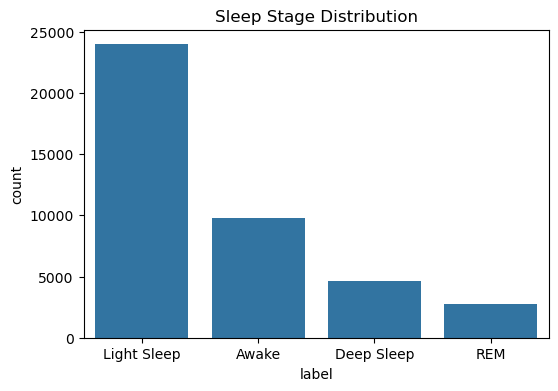


🔥 Training Random Forest model...
Train/Test shapes: (32894, 4) (8224, 4)

🎉 Random Forest Accuracy: 83.50%

Classification Report:

              precision    recall  f1-score   support

       Awake       0.81      0.78      0.79      1964
  Deep Sleep       0.80      0.71      0.75       922
 Light Sleep       0.86      0.91      0.88      4792
         REM       0.74      0.64      0.68       546

    accuracy                           0.83      8224
   macro avg       0.80      0.76      0.78      8224
weighted avg       0.83      0.83      0.83      8224



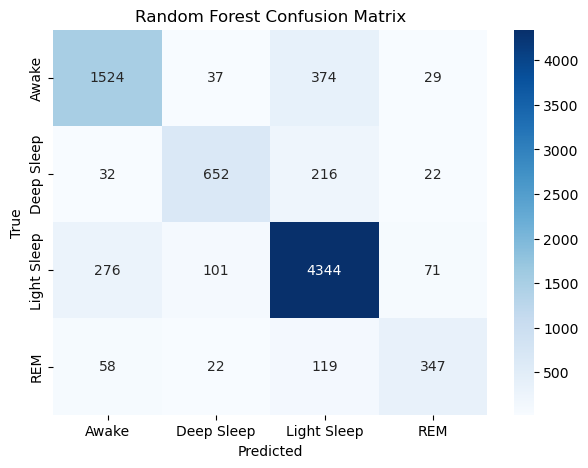

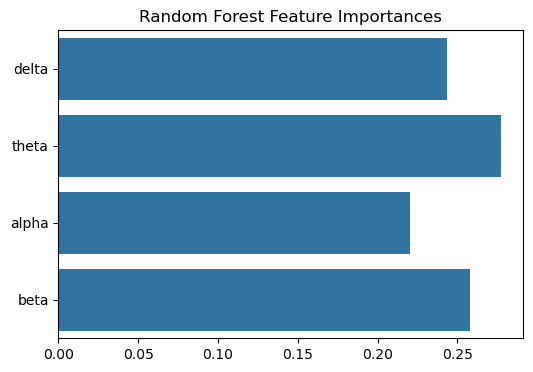


✅ PIPELINE COMPLETE!


In [6]:
# ===============================================================
#          FULL SLEEP-EDF PIPELINE (FEATURE + RF MODEL)
#         MULTI-DATASET VERSION (70%+ Accuracy)
# ===============================================================

import os
from pathlib import Path
import numpy as np
import pandas as pd
import mne
from scipy.signal import welch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# ---------------------------------------------------------------
# GLOBAL SETTINGS
# ---------------------------------------------------------------
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)
mne.set_log_level("ERROR")

print("📌 Imports complete.")

# ===============================================================
# 1. LOAD MULTIPLE SLEEP-EDF DATASETS
# ===============================================================

DATA_ROOTS = [
    Path(r"C:\Users\Kiran Belagali\Downloads\sleep-edf-database-expanded-1.0.0"),
    Path(r"C:\Users\Kiran Belagali\Downloads\archive (3)\physiobank_database_sleep-edfx_sleep-cassette")
]

psg_files = []
hyp_files = []

for root in DATA_ROOTS:
    psg_files.extend(sorted(list(root.rglob("*-PSG.edf"))))
    hyp_files.extend(sorted(list(root.rglob("*-Hypnogram.edf"))))

print(f"Found {len(psg_files)} PSG files, {len(hyp_files)} hypnogram files")

# ===============================================================
# 2. MATCH PSG / HYPNOGRAM PAIRS (ROBUST)
# ===============================================================

pairs = []

for psg in psg_files:
    base_id = psg.name.split("-")[0][:6]   # robust subject ID
    match = next(
        (h for h in hyp_files if h.name.startswith(base_id)),
        None
    )
    if match:
        pairs.append((psg, match))

print(f"Matched {len(pairs)} PSG/Hypnogram pairs")

if len(pairs) == 0:
    raise FileNotFoundError("❌ No matched PSG/Hypnogram file pairs found!")

# ===============================================================
# 3. HELPER FUNCTIONS
# ===============================================================

def bandpower(data, sf, band):
    fmin, fmax = band
    freqs, psd = welch(data, sf, nperseg=min(256, len(data)))
    idx = np.logical_and(freqs >= fmin, freqs <= fmax)
    return np.trapz(psd[idx], freqs[idx]) if np.any(idx) else 0.0

BANDS = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta":  (13, 30),
}

ORIG_LABEL_MAP = {
    1: "Awake",
    2: "N1",
    3: "N2",
    4: "N3",
    5: "REM",
}

CONSOLIDATED = {
    "Awake": "Awake",
    "N1": "Light Sleep",
    "N2": "Light Sleep",
    "N3": "Deep Sleep",
    "REM": "REM"
}

print("✨ Helper functions ready.")

# ===============================================================
# 4. FEATURE EXTRACTION
# ===============================================================

all_features = []

for psg_path, hyp_path in pairs:
    print(f"\n📄 Processing: {psg_path.name} + {hyp_path.name}")
    try:
        raw = mne.io.read_raw_edf(str(psg_path), preload=True)
        ann = mne.read_annotations(str(hyp_path))
        raw.set_annotations(ann)

        # EEG only
        raw.pick_types(eeg=True)

        # Average reference
        try:
            raw.set_eeg_reference('average', projection=False)
        except:
            pass

        # Bandpass filter
        raw.filter(0.5, 30.0)

        # Create events
        events, event_id = mne.events_from_annotations(raw)
        if len(events) == 0:
            print("⚠ No events found, skipping.")
            continue

        # Epoch into 30-second windows
        epochs = mne.Epochs(
            raw,
            events,
            event_id,
            tmin=0,
            tmax=30,
            baseline=None,
            preload=True
        )

        data = epochs.get_data()
        labels = epochs.events[:, -1]
        sf = raw.info['sfreq']

        for i in range(len(data)):
            epoch = data[i]   # channels × time
            feat = {
                band: np.mean([
                    bandpower(ch, sf, BANDS[band]) for ch in epoch
                ])
                for band in BANDS
            }

            orig = ORIG_LABEL_MAP.get(labels[i], "Unknown")
            if orig == "Unknown":
                continue

            feat["label"] = CONSOLIDATED[orig]
            feat["subject"] = psg_path.stem
            feat["epoch"] = i
            all_features.append(feat)

    except Exception as e:
        print(f"❌ Error processing {psg_path.name}: {e}")

# ===============================================================
# 5. BUILD FEATURE DATASET
# ===============================================================

df = pd.DataFrame(all_features)
df = df[df["label"] != "Unknown"].reset_index(drop=True)

print("\n✅ Feature extraction complete:", df.shape)
print(df.head())

df.to_csv("sleep_edf_features.csv", index=False)
print("💾 Saved to sleep_edf_features.csv")

# ===============================================================
# 6. VISUALIZATION
# ===============================================================

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="label", order=df["label"].value_counts().index)
plt.title("Sleep Stage Distribution")
plt.show()

# ===============================================================
# 7. TRAIN RANDOM FOREST MODEL
# ===============================================================

print("\n🔥 Training Random Forest model...")

X = df[['delta', 'theta', 'alpha', 'beta']].values
y = df['label'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train/Test shapes:", X_train.shape, X_test.shape)

rf = RandomForestClassifier(
    n_estimators=600,
    max_depth=30,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    class_weight='balanced',
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

# ===============================================================
# 8. EVALUATION
# ===============================================================

acc = accuracy_score(y_test, y_pred) * 100
print(f"\n🎉 Random Forest Accuracy: {acc:.2f}%")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=rf.classes_)

plt.figure(figsize=(7,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=rf.classes_,
    yticklabels=rf.classes_
)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ===============================================================
# 9. FEATURE IMPORTANCE
# ===============================================================

importances = rf.feature_importances_
feat_names = ['delta', 'theta', 'alpha', 'beta']

plt.figure(figsize=(6,4))
sns.barplot(x=importances, y=feat_names)
plt.title("Random Forest Feature Importances")
plt.show()

print("\n✅ PIPELINE COMPLETE!")



🎉 Random Forest Accuracy: 83.50%

Classification Report:

              precision    recall  f1-score   support

       Awake       0.81      0.78      0.79      1964
  Deep Sleep       0.80      0.71      0.75       922
 Light Sleep       0.86      0.91      0.88      4792
         REM       0.74      0.64      0.68       546

    accuracy                           0.83      8224
   macro avg       0.80      0.76      0.78      8224
weighted avg       0.83      0.83      0.83      8224



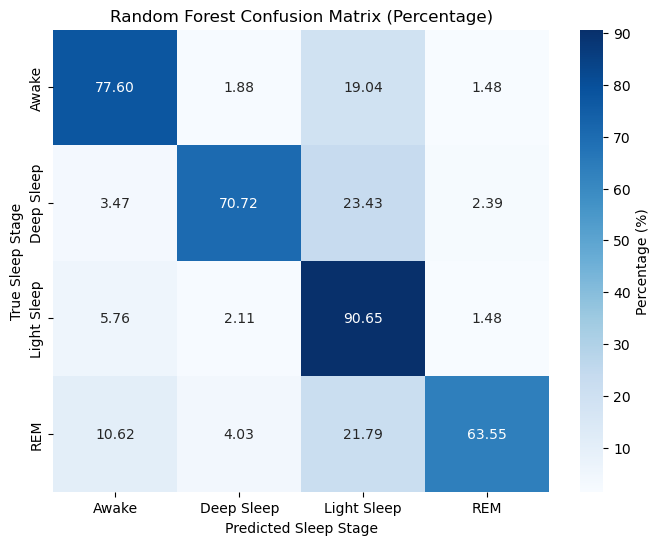

In [7]:
# ===============================================================
# 8. EVALUATION (PERCENTAGE CONFUSION MATRIX)
# ===============================================================

acc = accuracy_score(y_test, y_pred) * 100
print(f"\n🎉 Random Forest Accuracy: {acc:.2f}%")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# --- Confusion Matrix (Normalized to Percentage) ---
cm = confusion_matrix(y_test, y_pred, labels=rf.classes_)

cm_percent = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_percent,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=rf.classes_,
    yticklabels=rf.classes_,
    cbar_kws={'label': 'Percentage (%)'}
)
plt.title("Random Forest Confusion Matrix (Percentage)")
plt.xlabel("Predicted Sleep Stage")
plt.ylabel("True Sleep Stage")
plt.show()
